# Description

In this notebook, I will
- Load the code
- Create feature embedding 
- Train classifier model

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch 
import torch.nn as nn
import transformers
from transformers import AutoTokenizer, AutoModel

# 1. Load dataset

In [2]:
PATH_GENERATED_DATA_FOLDER = "data/generated"


In [3]:
list_files = os.listdir(PATH_GENERATED_DATA_FOLDER)
list_csv_files = [f for f in list_files if f.endswith('.csv')]
print(f"List of generated CSV files: ")
list_csv_files

List of generated CSV files: 


['human_eval_generated_deepseek.csv',
 'human_eval_generated_gpt4o.csv',
 'human_eval_generated_qwen_TDD.csv',
 'human_eval_generated_deepseek_COT.csv',
 'human_eval_generated_qwen.csv',
 'human_eval_generated_deepseek_TDD.csv',
 'human_eval_generated_qwen_COT.csv',
 'human_eval_generated_gpt4o_COT.csv']

In [4]:
df = pd.DataFrame()
for file in list_csv_files:
    current_df = pd.read_csv(os.path.join(PATH_GENERATED_DATA_FOLDER, file))
    print(f"{file}: {current_df.shape[0]} rows, {current_df.shape[1]} columns")
    df = pd.concat([df, current_df], ignore_index=True)

print()
print(f"Shape of combined dataframe: {df.shape}")
df.sample()

human_eval_generated_deepseek.csv: 163 rows, 7 columns
human_eval_generated_gpt4o.csv: 164 rows, 7 columns
human_eval_generated_qwen_TDD.csv: 164 rows, 7 columns
human_eval_generated_deepseek_COT.csv: 164 rows, 7 columns
human_eval_generated_qwen.csv: 163 rows, 7 columns
human_eval_generated_deepseek_TDD.csv: 161 rows, 7 columns
human_eval_generated_qwen_COT.csv: 164 rows, 8 columns
human_eval_generated_gpt4o_COT.csv: 164 rows, 8 columns

Shape of combined dataframe: (1307, 8)


,description,generated_code,test_case,entry_point,total_asserts,passed_asserts,percentage,reasoning_text
1209,"\ndef digitSum(s):\n """"""Task\n Write a f...","def digitSum(s):\n """"""Task\n Write a fun...",def check(candidate):\n\n # Check some simp...,digitSum,10,10,1.0,1. **Function Objective**: The function needs ...


# 2. Construct dataset

Label is percent of test cases passed

In [5]:
idx = np.random.randint(0, df.shape[0])
gen_code = df.loc[idx, 'generated_code']
test_case = df.loc[idx, 'test_case']
entry_point = df.loc[idx, 'entry_point']

label = df.loc[idx, 'percentage']

print("Generated code:")
print(gen_code)
print("\nTest case:")
print(test_case)

if label == 1.0:
    print("\n[PASS]")
elif 0 < label < 1.0:
    print("\n[PARTIAL PASS]")
else:
    print("\n[FAIL]")

Generated code:
def add(lst):
    return sum(lst[i] for i in range(1, len(lst), 2) if lst[i] % 2 == 0)

Test case:
def check(candidate):

    # Check some simple cases
    assert candidate([4, 88]) == 88
    assert candidate([4, 5, 6, 7, 2, 122]) == 122
    assert candidate([4, 0, 6, 7]) == 0
    assert candidate([4, 4, 6, 8]) == 12

    # Check some edge cases that are easy to work out by hand.
    


[PASS]


## 2.1. Perform code embedding

In [6]:
# Load model + tokenizer
model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

In [7]:
def embed_code(code_snippet: str):
    # Tokenize input
    inputs = tokenizer(code_snippet, return_tensors="pt", truncation=True, padding=True)
    
    # Get model outputs
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Use CLS token embedding as the vector
    embeddings = outputs.last_hidden_state[:, 0, :]
    return embeddings.squeeze().numpy()

In [8]:
df.sample()

,description,generated_code,test_case,entry_point,total_asserts,passed_asserts,percentage,reasoning_text
1183,"\n\ndef triples_sum_to_zero(l: list):\n """"""...","def triples_sum_to_zero(l: list):\n """"""\n ...",\n\nMETADATA = {}\n\n\ndef check(candidate):\n...,triples_sum_to_zero,9,9,1.0,1. **What the function must do:**\n The func...


In [9]:
list_code_embeddings = []
list_test_embeddings = []
list_labels = []

for i in range(df.shape[0]):
    
    # Positive sample
    code_script = df.loc[i, 'generated_code']
    test_case_script = df.loc[i, 'test_case']
    
    code_embedding = embed_code(code_script)
    test_embedding = embed_code(test_case_script)
    label = df.loc[i, 'percentage']
    if label > 0.5:
        label = 1.0
    else:
        label = 0.0

    list_code_embeddings.append(code_embedding)
    list_test_embeddings.append(test_embedding)
    list_labels.append(label)
    
    # To create negative sample, randomly select n test embedding from another code snippet
    n_neg_samples = 1
    for _ in range(n_neg_samples):
        rand_idx = np.random.randint(0, df.shape[0])
        while rand_idx == i:
            rand_idx = np.random.randint(0, df.shape[0])
        neg_test_case_script = df.loc[rand_idx, 'test_case']
        neg_test_embedding = embed_code(neg_test_case_script)
        
        list_code_embeddings.append(code_embedding)
        list_test_embeddings.append(neg_test_embedding)
        list_labels.append(0.0)
    
X_code = np.array(list_code_embeddings)
X_test =  np.array(list_test_embeddings)
y = np.array(list_labels)

print(f"Shape of code embeddings: {X_code.shape}")
print(f"Shape of test embeddings: {X_test.shape}")
print(f"Shape of labels: {y.shape}")

Shape of code embeddings: (2614, 768)
Shape of test embeddings: (2614, 768)
Shape of labels: (2614,)


In [10]:
# Number of samples per class
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution (label: count):")
for label, count in class_distribution.items():
    print(f"  {label}: {count}")

Class distribution (label: count):
  0.0: 1402
  1.0: 1212


## 2.2. Data Exploration

In [39]:
idx = np.random.randint(0, X_code.shape[0])

code_embedding = X_code[idx]
test_embedding = X_test[idx]
label = y[idx]

distance = np.linalg.norm(code_embedding - test_embedding)
print(f"Label: {label}")
print(f"Euclidean distance between code and test embeddings: {distance}")

Label: 1.0
Euclidean distance between code and test embeddings: 4.790119171142578


# 3. Define model

In [11]:
class CodeEvalModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(CodeEvalModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(p=0.2)
        # self.scales = nn.Parameter(torch.zeros(2))
        
    def forward(self, code_embedd, test_embedd):
        x_c = self.fc1(code_embedd)
        x_c = self.relu(x_c)
        x_c = self.dropout(x_c)
        
        x_t = self.fc2(test_embedd)
        x_t = self.relu(x_t)
        x_t = self.dropout(x_t)
        
        x = torch.cat((x_c, x_t), dim=1)
        x = self.fc3(x)
        return x

In [12]:
# Define model with hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_code.shape[1]
hidden_dim = 128

model = CodeEvalModel(input_dim, hidden_dim)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters in model: {total_params}")
print(model)

Total parameters in model: 197121
CodeEvalModel(
  (fc1): Linear(in_features=768, out_features=128, bias=True)
  (fc2): Linear(in_features=768, out_features=128, bias=True)
  (relu): ReLU()
  (fc3): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [14]:
# Prepare data for training
from torch.utils.data import DataLoader, TensorDataset, random_split
tensor_X_code = torch.tensor(X_code, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

In [15]:
# Train-validation-test split
dataset = TensorDataset(tensor_X_code, tensor_X_test, tensor_y)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [16]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. Training 

In [17]:
# Training process
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

criterion = nn.BCEWithLogitsLoss()

In [20]:
def train(model, loader, criterion, optimizer, device='cuda'):
    model.train()
    running_loss = 0.0
    
    for code_embedd, test_embedd, labels in loader:
        code_embedd = code_embedd.to(device)
        test_embedd = test_embedd.to(device)
        labels = labels.to(device).float()       # for BCEWithLogitsLoss

        optimizer.zero_grad()
        
        outputs = model(code_embedd, test_embedd)    # [B, 1]
        outputs = outputs.squeeze(1)                 # [B]
        labels = labels.squeeze(1)                   # [B]
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * code_embedd.size(0)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def evaluate(model, loader, criterion, device='cuda'):
    model.eval()
    running_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for code_embedd, test_embedd, labels in loader:
            code_embedd = code_embedd.to(device)
            test_embedd = test_embedd.to(device)
            labels = labels.to(device).float()

            outputs = model(code_embedd, test_embedd)    # [B, 1]
            outputs = outputs.squeeze(1)                 # [B]
            labels = labels.squeeze(1)                   # [B]
            
            loss = criterion(outputs, labels)
            running_loss += loss.item() * code_embedd.size(0)

            # logits -> probs
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            correct += (preds == labels.round()).sum().item()
    
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return epoch_loss, accuracy

train_losses = []
val_losses = []
val_accuracies = []


for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Val Acc: {val_accuracy:.4f}")

Epoch 1/10, Train Loss: 0.6879, Val Loss: 0.6973, Val Acc: 0.5134
Epoch 2/10, Train Loss: 0.6881, Val Loss: 0.6946, Val Acc: 0.5134
Epoch 3/10, Train Loss: 0.6866, Val Loss: 0.6950, Val Acc: 0.5134
Epoch 4/10, Train Loss: 0.6863, Val Loss: 0.6948, Val Acc: 0.5134
Epoch 5/10, Train Loss: 0.6868, Val Loss: 0.6950, Val Acc: 0.5134
Epoch 6/10, Train Loss: 0.6853, Val Loss: 0.6928, Val Acc: 0.5134
Epoch 7/10, Train Loss: 0.6868, Val Loss: 0.6924, Val Acc: 0.4866
Epoch 8/10, Train Loss: 0.6839, Val Loss: 0.6922, Val Acc: 0.4751
Epoch 9/10, Train Loss: 0.6867, Val Loss: 0.6920, Val Acc: 0.4981
Epoch 10/10, Train Loss: 0.6832, Val Loss: 0.7033, Val Acc: 0.5134


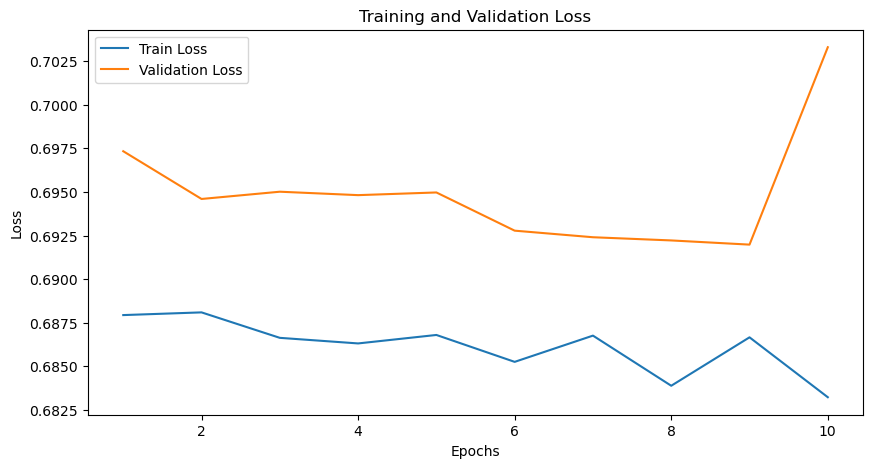

In [21]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [22]:
# evaluate on test set
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6969, Test Accuracy: 0.5115
